In [82]:
import os
import json
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

repo = '<path to your repo>'

# Load data from repo

Load model checking memory usage data for each model checking run and concatenate datasets.

In [83]:
df_01 = pd.read_csv(repo+'/01/01model_check.csv', header=[0], index_col=[0])
df_11 = pd.read_csv(repo+'/11/11model_check.csv', header=[0], index_col=[0])

df_01['run'] = 0
df_11['run'] = 1

df_mc = pd.concat([df_01, df_11])
print(df_mc.head())

   stack_size  set_size  state_size  n_states  adj_list_compile  \
0           5        15           4        15               184   
1           5        15           4        15               184   
2           5        15           4        15               184   
3           5         7           4        15               184   
4           4         4           4        15               184   

   stack_compile  set_compile  run  
0             12           24    0  
1             12           24    0  
2             12           24    0  
3             12           24    0  
4             12           24    0  


Load process memory usage data for each (model checking and baseline) and concatenate datasets.

In [105]:
df_usage_01 = pd.read_csv(repo+'/01/01usage.csv', header=[0], index_col=[0])
df_usage_02 = pd.read_csv(repo+'/02/02usage.csv', header=[0], index_col=[0])
df_usage_11 = pd.read_csv(repo+'/11/11usage.csv', header=[0], index_col=[0])
df_usage_12 = pd.read_csv(repo+'/12/12usage.csv', header=[0], index_col=[0])

df_usage_01['run'] = 0
df_usage_01['method'] = 'multi'
df_usage_02['run'] = 0
df_usage_02['method'] = 'single'

df_usage_11['run'] = 1
df_usage_11['method'] = 'multi'
df_usage_12['run'] = 1
df_usage_12['method'] = 'single'

df_usage = pd.concat([df_usage_01, df_usage_02, df_usage_11, df_usage_12])
print(df_usage.head())

     pr   ni     virt     res     shr status  cpu_perc  mem_perc  cpu_time  \
0  20.0  0.0  37536.0  3528.0  2904.0      S       6.7       0.4      0.58   
1  20.0  0.0  37536.0  3528.0  2904.0      S       0.0       0.4      0.58   
2  20.0  0.0  37536.0  3528.0  2904.0      S       0.0       0.4      0.58   
3  20.0  0.0  37536.0  3528.0  2904.0      S       0.0       0.4      0.58   
4  20.0  0.0  37536.0  3528.0  2904.0      S       0.0       0.4      0.58   

   mem_total  mem_free  mem_used  cache  swap_total  swap_free  swap_used  \
0      922.0     642.0      81.5  197.0       100.0      100.0        0.0   
1      922.0     642.0      81.5  197.0       100.0      100.0        0.0   
2      922.0     642.0      81.5  197.0       100.0      100.0        0.0   
3      922.0     642.0      81.5  197.0       100.0      100.0        0.0   
4      922.0     642.0      81.5  197.0       100.0      100.0        0.0   

   process_uptime  run method  
0           0.000    0  multi  
1   

Load plan data extracted from `autoctrl.txt` for each model checking run and concatanate datasets.

In [85]:
df_plan_01 = pd.read_csv(repo+'/01/01plan.csv', header=[0], index_col=[0])
df_plan_11 = pd.read_csv(repo+'/11/11plan.csv', header=[0], index_col=[0])

df_plan_01['run'] = 0
df_plan_11['run'] = 1

df_plan = pd.concat([df_plan_01, df_plan_11])
df_mc['steps'] = df_plan.steps.values
print(df_plan.head())

  accept     path                                  plan  latency  steps  run
0      3      0 1                       left -> default    8.841      2    0
1      3      0 1                       left -> default    7.212      2    0
2      4      0 2                      right -> default    4.395      2    0
3   8 12  0 2 4 6  right -> straight -> left -> default    5.864      4    0
4     11  0 1 3 9   left -> straight -> left -> default   14.022      4    0


# Plan execution and processing latency

Check the number of plans generated by model checking for each run is consistent. 

In [86]:
df_plan[df_plan.run == 0].count()

accept     50
path       50
plan       50
latency    54
steps      54
run        54
dtype: int64

Inconsistent counts here. 

NOTE: Inspecting the log for model checking for run 0 (i.e., comparison 0) shows that the robot had to retry planning 4 times at one point before producing a plan.  So there is no `accept`, `path` or `plan` data for these planning attempts, but there is `latency`, `steps` (= 0) and `run`.  As there is no plan data, we can remove these rows from the analysis.  Also shows that our method can recover when a plan has failed to be generated, as intended.  

In [87]:
# remove any 0 step plans
df_plan = df_plan[df_plan.steps != 0]
df_plan[df_plan.run == 0].count()

accept     50
path       50
plan       50
latency    50
steps      50
run        50
dtype: int64

In [88]:
df_plan[df_plan.run == 1].count()

accept     46
path       46
plan       46
latency    46
steps      46
run        46
dtype: int64

Everything looks good here now. 

### Number of n-step plans

Quick look at the counts of n-step plans for each run for completeness. 

<Axes: xlabel='run', ylabel='count'>

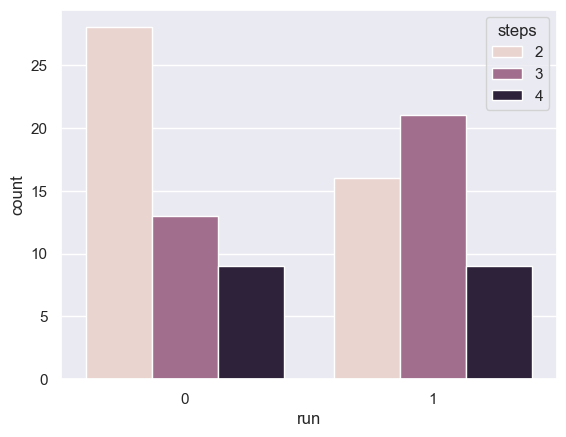

In [89]:
sns.countplot(df_plan.dropna(axis=0), x='run', hue='steps')

However, we are interested on the number of n-step plans across both runs (i.e., comparisons).

In [90]:
print(f'N of 2-step plans: {len(df_plan[df_plan.steps == 2])}')
print(f'N of 3-step plans: {len(df_plan[df_plan.steps == 3])}')
print(f'N of 4-step plans: {len(df_plan[df_plan.steps == 4])}')

N of 2-step plans: 44
N of 3-step plans: 34
N of 4-step plans: 18


<Axes: xlabel='steps', ylabel='count'>

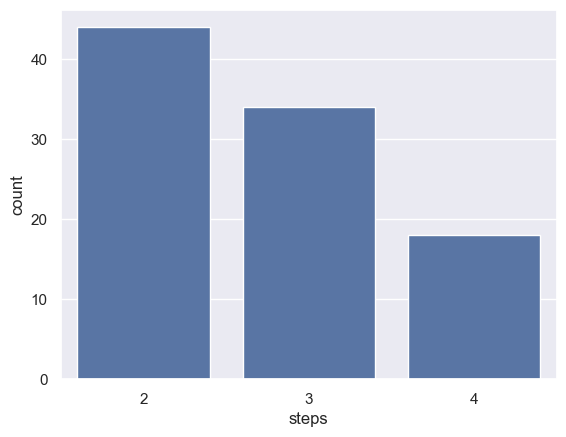

In [91]:
sns.countplot(df_plan.dropna(axis=0), x='steps')

### Comparison of processing latency

Quick comparison of the distributions of processing latency for each n-step plan and run. 

<Axes: xlabel='run', ylabel='latency'>

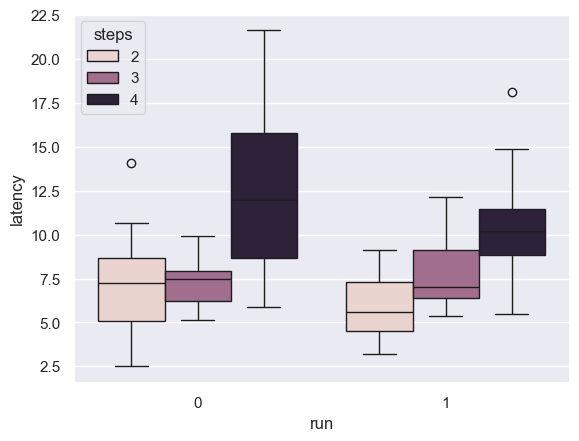

In [92]:
sns.boxplot(df_plan.dropna(axis=0), x='run', y='latency', hue='steps')

However, we are interested in processing latency for n-step plans across all model checking runs. 

Descriptive stats for processing latency for each n-step plan - we are interested in the min, max and mean. 

In [106]:
# descriptive stats for 2-step plans
df_plan[df_plan.steps == 2].dropna(axis=0).latency.describe()

count    44.000000
mean      6.601795
std       2.495903
min       2.497000
25%       4.644250
50%       6.294500
75%       8.400000
max      14.092000
Name: latency, dtype: float64

In [107]:
# descriptive state for 3-step plans
df_plan[df_plan.steps == 3].dropna(axis=0).latency.describe()

count    34.000000
mean      7.569529
std       1.790372
min       5.124000
25%       6.340500
50%       7.096000
75%       8.651500
max      12.150000
Name: latency, dtype: float64

In [109]:
## descriptive stats for 4-step plans
df_plan[df_plan.steps == 4].dropna(axis=0).latency.describe()

count    18.000000
mean     11.490778
std       4.666868
min       5.456000
25%       8.701750
50%      10.239500
75%      14.651250
max      21.618000
Name: latency, dtype: float64

<Axes: xlabel='steps', ylabel='latency'>

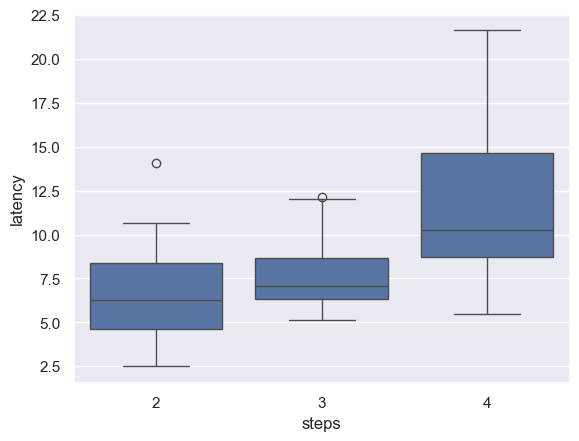

In [96]:
sns.boxplot(df_plan.dropna(axis=0), x='steps', y='latency')

Estimate 95% confidence bounds on mean processing latency for each n-step plan.  

ConfidenceInterval(low=np.float64(5.919703191431834), high=np.float64(7.379845000411803))


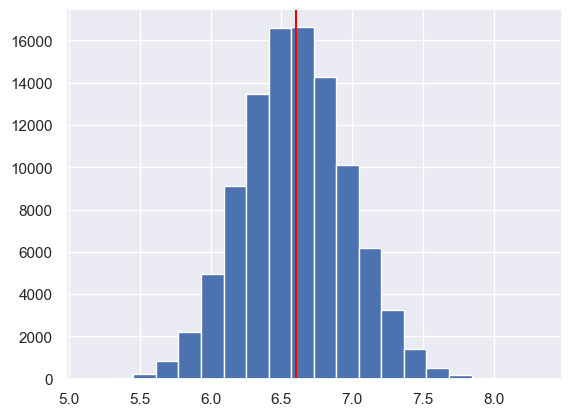

In [97]:
# 95% confidence bounds for 2-step plans
result = stats.bootstrap((df_plan[df_plan.steps == 2].latency, ), 
                          statistic=np.mean, 
                          n_resamples=100000,
                          confidence_level=0.95)

reference = df_plan[df_plan.steps == 2].latency.mean()
plt.hist(result.bootstrap_distribution, bins=20)
plt.axvline(reference, color='red')
print(result.confidence_interval)

ConfidenceInterval(low=np.float64(7.037783655366083), high=np.float64(8.23443260299949))


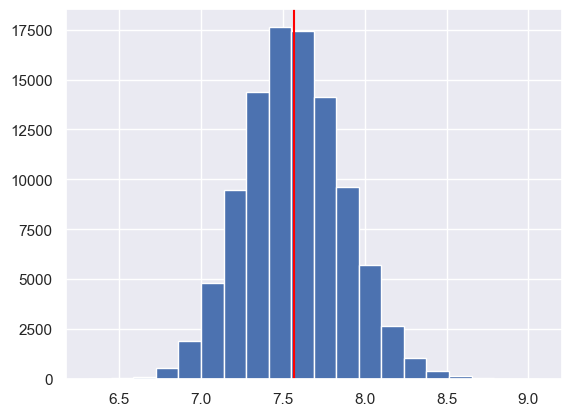

In [110]:
# 95% confidence bounds for 3-step plans
result = stats.bootstrap((df_plan[df_plan.steps == 3].latency, ), 
                          statistic=np.mean, 
                          n_resamples=100000,
                          confidence_level=0.95)

reference = df_plan[df_plan.steps == 3].latency.mean()
plt.hist(result.bootstrap_distribution, bins=20)
plt.axvline(reference, color='red')
print(result.confidence_interval)

ConfidenceInterval(low=np.float64(9.60142639541214), high=np.float64(13.82295915197))


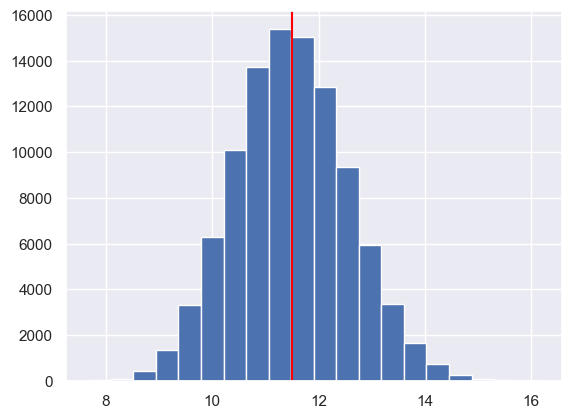

In [111]:
# 95% confidence bounds for 4-step plans
result = stats.bootstrap((df_plan[df_plan.steps == 4].latency, ), 
                          statistic=np.mean, 
                          n_resamples=100000,
                          confidence_level=0.95)

reference = df_plan[df_plan.steps == 4].latency.mean()
plt.hist(result.bootstrap_distribution, bins=20)
plt.axvline(reference, color='red')
print(result.confidence_interval)

# Model checking memory usage

In [100]:
print(df_mc.head())

   stack_size  set_size  state_size  n_states  adj_list_compile  \
0           5        15           4        15               184   
1           5        15           4        15               184   
2           5        15           4        15               184   
3           5         7           4        15               184   
4           4         4           4        15               184   

   stack_compile  set_compile  run  steps  
0             12           24    0      2  
1             12           24    0      2  
2             12           24    0      2  
3             12           24    0      4  
4             12           24    0      4  


In [101]:
result = ((df_mc.stack_size * df_mc.state_size) + \
(df_mc.set_size * df_mc.state_size) + \
(df_mc.n_states * df_mc.state_size) + \
df_mc.adj_list_compile + df_mc.set_compile + df_mc.stack_compile)

print('Worst case model checking memory usage: {} bytes'.format(result.max()))

Worst case model checking memory usage: 360 bytes


# Process memory usage

Worst case memory usage of the process at runtime across all runs.  

Note that `RES` is the total amount of allocated memory in KB and `SHR` is the amount of memory that could be shared with other processes in KB, as per the Linux top utility.  So for every 1ms sample collected during a run, the actual memory used by the process ranges between `RES - SHR` (lower bound) and `RES` (upper bound).  However, we are only interested in the worst case usage for each run, so for each run we have extracted from the dataset generated by Linux top the maximum for each of these values.  These are the dataset variables `shr` and `res` which have a strong positive correlation. In the analysis below, we therefore calculate the worst case usage across all runs by finding the max of the per run maximums.  This gives us the worst case lower bound and the worst case upper bound for all model checking runs. 

In [114]:
test = df_usage[df_usage.method == 'multi']
print(test[['shr', 'res']].corr())

          shr       res
shr  1.000000  0.926551
res  0.926551  1.000000


In [102]:
(df_usage[df_usage.method == 'multi'].res - df_usage[df_usage.method == 'multi'].shr).max(), df_usage[df_usage.method == 'multi'].res.max() / 1024

(1088.0, 4.09375)

Let us double check that the max difference `res - shr` is associated with the max `res`.  

In [116]:
diff = (df_usage[df_usage.method == 'multi'].res - df_usage[df_usage.method == 'multi'].shr)
print(diff.head())

0    624.0
1    624.0
2    624.0
3    624.0
4    624.0
dtype: float64


Should be fine but reset index just in case out of sync.

In [117]:
diff = diff.reset_index(drop='index')
print(diff.head())

0    624.0
1    624.0
2    624.0
3    624.0
4    624.0
dtype: float64


Now check that the index of the maximum difference returns the same values. 

In [119]:
# ensure indices line up for each dataframe
res = df_usage[df_usage.method == 'multi'].res.reset_index(drop='index')
print(res.head())

0    3528.0
1    3528.0
2    3528.0
3    3528.0
4    3528.0
Name: res, dtype: float64


In [120]:
# index of max diff
idx = diff.idxmax()
# check bounds match
diff[idx], res[idx] / 1024

(np.float64(1088.0), np.float64(4.09375))